# 03 Suggestion analysis

Run notebooks 01 and 02 first. Here we read optional comments and count simple keywords. We use normal `if` statements so you can see exactly what is counted.

One comment may mention several topics. A blank comment means no suggestion was recorded, not that the resident had no concerns.

## 1. Read the clean data

In [1]:
# Pandas helps us work with tables.
import pandas as pd

# os helps us check where the data folder is.
import os

# Start by looking in the project folder.
project_folder = "."

# A notebook may start inside the notebooks folder instead.
if not os.path.exists("data/raw/survey_responses_raw.csv"):

    # Two dots mean the folder one level above this one.
    project_folder = ".."

# Matplotlib creates the suggestion chart.
import matplotlib.pyplot as plt

# Read the clean Tilak Nagar data and keep empty comments as empty text.
data = pd.read_csv(project_folder + "/data/processed/tilak_nagar_clean.csv", keep_default_na=False)

# Select only recorded comments.
comments = data[data["suggestion"] != ""]["suggestion"]

# Show how many comments are available.
print("Recorded comments:", len(comments))
print("Blank comments:", len(data) - len(comments))

Recorded comments: 15
Blank comments: 11


## 2. Read the comments yourself
Keywords can miss context or spelling. Review the comments before drawing conclusions. These comments are for private project review; clear this cell’s output before public sharing.

In [2]:
# Visit each recorded comment.
for comment in comments:

    # Print the original suggestion.
    print(comment)

    # Add a blank line between suggestions.
    print()

In Tilak nagar we need parking place

Required services of Footpath condition and garbage collection ASAP ,i suggest not only about government to corporate but the  public also need to improve their bad habits like throwing garbages in guttar and roads .they should use dustbins provided by government..

Need cleaning in some places

Toilets needs to be clean

Traffic

noise pollution by honking

traffic problem needs to be resolve

toilets needs to be clean regularly

better drainage systems

need street light in some places

toilets cleaning is major problem

roads

footpaths and roads

there is no toilets in some places

complaint systems should work faster



## 3. Start every theme count at zero
A counter is a variable that increases when we find a matching comment.

In [3]:
# Start a separate counter for each theme.
road_count = 0

toilet_count = 0

garbage_count = 0

cleanliness_count = 0

drainage_count = 0

lighting_count = 0

traffic_count = 0

complaint_count = 0

## 4. Count keyword matches
`lower()` changes capital letters to small letters. `in` checks whether a word appears. `or` means either keyword may match. Each `if` adds at most one to that theme for a comment. Separate `if` statements allow several themes in one comment.

In [4]:
# Look at one comment at a time.
for comment in comments:

    # Use small letters so matching ignores capitalisation.
    comment = comment.lower()

    # Count a roads or footpaths mention.
    if "road" in comment or "footpath" in comment:
        road_count = road_count + 1

    # Count a public toilets mention.
    if "toilet" in comment:
        toilet_count = toilet_count + 1

    # Count a garbage collection mention.
    if "garbage" in comment or "dustbin" in comment:
        garbage_count = garbage_count + 1

    # Count a cleanliness mention.
    if "clean" in comment or "cleanness" in comment:
        cleanliness_count = cleanliness_count + 1

    # Count drainage words, including a spelling used in the source.
    if "drain" in comment or "guttar" in comment or "sewage" in comment:
        drainage_count = drainage_count + 1

    # Count a street lighting mention.
    if "street light" in comment:
        lighting_count = lighting_count + 1

    # Count a traffic or parking mention.
    if "traffic" in comment or "parking" in comment or "honking" in comment:
        traffic_count = traffic_count + 1

    # Count a complaint-system mention.
    if "complaint" in comment:
        complaint_count = complaint_count + 1

## 5. Save the theme table
Each inner list contains a theme name and its count. The table goes to the website.

In [5]:
# Put each theme and count into a row.
theme_rows = [
    ["Roads and footpaths", road_count],
    ["Public toilets", toilet_count],
    ["Garbage collection", garbage_count],
    ["Cleanliness", cleanliness_count],
    ["Drainage", drainage_count],
    ["Street lighting", lighting_count],
    ["Traffic and parking", traffic_count],
    ["Complaint systems", complaint_count],
]

# Make a table with two named columns.
themes = pd.DataFrame(theme_rows, columns=["theme", "mentions"])

# Put the most-mentioned themes first.
themes = themes.sort_values("mentions", ascending=False)

# Save the results for the website.
themes.to_csv(project_folder + "/data/processed/suggestion_theme_counts.csv", index=False)

# Display the theme counts.
themes

,theme,mentions
1,Public toilets,4
3,Cleanliness,4
6,Traffic and parking,4
0,Roads and footpaths,3
4,Drainage,2
2,Garbage collection,1
5,Street lighting,1
7,Complaint systems,1


## 6. Draw the theme chart
Theme counts can add up to more than the number of comments because one comment can match several themes.

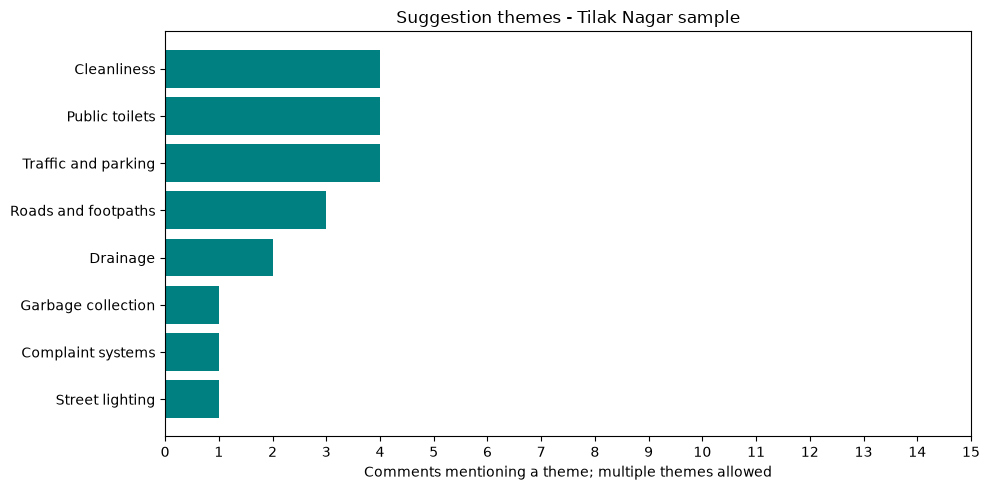

In [6]:
# Order the bars so the largest appear at the top.
chart_data = themes.sort_values("mentions")

# Draw one bar for each theme.
plt.figure(figsize=(10, 5))
plt.barh(chart_data["theme"], chart_data["mentions"], color="teal")

# Label the chart and use whole-number count marks.
plt.title("Suggestion themes - Tilak Nagar sample")
plt.xlabel("Comments mentioning a theme; multiple themes allowed")
plt.xticks(range(0, len(comments) + 1))

# Fit the chart, save it, and show it.
plt.tight_layout()
plt.savefig(project_folder + "/images/suggestion_themes.png", dpi=150)
plt.show()
plt.close()

## What to tell your teacher

“I read the comments and counted words such as toilet, road, garbage, and traffic. I used simple if statements. This is keyword counting, not machine learning.”

For the supplied data, **15** respondents left comments and **11** did not. Toilets, cleanliness, and traffic/parking each match **4** comments. Check the comments because keyword matches can miss context, negation, or spellings.

## Proposed community activities

1. Share aggregate findings with participating residents.
2. Ask which public toilet locations and service problems need attention.
3. Discuss garbage, lighting, roads, and the other reported concerns.
4. Prepare a summary for the appropriate representative or service office after verifying the contact.
5. Record actual meetings, submissions, feedback, and follow-up in `survey/community_activity_log.csv`.

These are proposals. No completed meeting, complaint submission, or improvement is claimed. Add only fieldwork details you can support with your actual records.